# transit-case simulation analysis

Loads all FITS outputs from `tests/test_transit_cases.py`,
plots the frequency-averaged response for Default vs Cro simulators,
and compares expected (geometric) transit times against the peaks found in the simulated data.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '../..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.time import Time
from astropy.coordinates import SkyCoord, GeocentricMeanEcliptic
from astropy import units as u
from scipy.signal import find_peaks

import lusee

/home/anze/venv/luseepy/lib/python3.11/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/anze/.config', but the default location, /home/anze/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


/home/anze/venv/luseepy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.
The croissant.jax interface is deprecated and will be removed in a future release. Please use the croissant interface directly instead.


## Case definitions

Matches `tests/test_transit_cases.py`.

In [ ]:
# transit cases from test_transit_cases.py
transit_CASES = [
    dict(name="i",   label="i:  beam alt=30, az=90,  src ecl_lon=70, ecl_lat=0",  beam_alt=30, beam_az=90,  ecl_lon=70, ecl_lat=0),
    dict(name="ii",  label="ii: beam alt=60, az=90,  src ecl_lon=70, ecl_lat=0",  beam_alt=60, beam_az=90,  ecl_lon=70, ecl_lat=0),
    dict(name="iii", label="iii:beam alt=60, az=270, src ecl_lon=70, ecl_lat=0",  beam_alt=60, beam_az=270, ecl_lon=70, ecl_lat=0),
    dict(name="iv",  label="iv: beam alt=30, az=270, src ecl_lon=70, ecl_lat=0",  beam_alt=30, beam_az=270, ecl_lon=70, ecl_lat=0),
    dict(name="v",   label="v:  beam alt=60, az=0,   src ecl_lon=70, ecl_lat=30", beam_alt=60, beam_az=0,   ecl_lon=70, ecl_lat=30),
    dict(name="vi",  label="vi: beam alt=60, az=180, src ecl_lon=70, ecl_lat=-30",beam_alt=60, beam_az=180, ecl_lon=70, ecl_lat=-30),
]

# Shared observation parameters
TIME_START  = "2025-03-01 00:00:00"
TIME_END    = "2025-03-29 00:00:00"
DELTA_T_SEC = 7200.0

FITS_DIR = os.path.abspath('../../tests')

def fits_paths(name):
    return (
        os.path.join(FITS_DIR, f'sim_output_default_case_{name}.fits'),
        os.path.join(FITS_DIR, f'sim_output_cro_case_{name}.fits'),
    )

## Helper functions

In [3]:
def freq_avg(D):
    """Frequency-averaged time stream, shape (Ntimes,)."""
    return np.mean(D.data[:, 0, :], axis=1)

def get_source_radec(ecl_lon_deg, ecl_lat_deg):
    c = SkyCoord(lon=ecl_lon_deg * u.deg, lat=ecl_lat_deg * u.deg, frame=GeocentricMeanEcliptic)
    return c.icrs.ra.deg, c.icrs.dec.deg

def angular_sep_deg(alt1_rad, az1_rad, alt2_rad, az2_rad):
    """Angular separation in degrees between two (alt, az) positions."""
    cos_dist = (np.sin(alt1_rad) * np.sin(alt2_rad)
                + np.cos(alt1_rad) * np.cos(alt2_rad) * np.cos(az1_rad - az2_rad))
    cos_dist = np.clip(cos_dist, -1, 1)
    return np.degrees(np.arccos(cos_dist))

def expected_transit_times(obs, ra_deg, dec_deg, beam_alt_deg, beam_az_deg):
    """
    Return list of (datetime, sep_deg) for local minima in angular separation
    between the source track and beam pointing direction.
    Only returns minima where sep < 2*sigma_deg (rough window).
    """
    alt_track, az_track = obs.get_track_ra_dec(ra_deg, dec_deg)
    alt_rad = np.asarray(alt_track, dtype=float)
    az_rad  = np.asarray(az_track,  dtype=float)
    beam_alt_rad = np.radians(beam_alt_deg)
    beam_az_rad  = np.radians(beam_az_deg)
    sep = angular_sep_deg(alt_rad, az_rad, beam_alt_rad, beam_az_rad)
    # find local minima (troughs in sep = peaks in -sep)
    min_idx, _ = find_peaks(-sep, prominence=1.0)
    times_dt = Time(obs.times).datetime
    return [(times_dt[i], sep[i]) for i in min_idx]

def actual_transit_times(times_dt, signal, min_prominence=0.01):
    """Return list of (datetime, value) for peaks in freq-averaged signal."""
    signal_norm = signal / signal.max() if signal.max() > 0 else signal
    peak_idx, props = find_peaks(signal_norm, prominence=min_prominence)
    return [(times_dt[i], signal[i]) for i in peak_idx]

## Build the shared Observation object

In [4]:
obs = lusee.Observation(
    f"{TIME_START} to {TIME_END}",
    deltaT_sec=DELTA_T_SEC,
    lun_lat_deg=0.0,
    lun_long_deg=0.0,
)
obs_times_dt = Time(obs.times).datetime
print(f"Ntimes = {len(obs.times)}, dt = {DELTA_T_SEC/3600:.1f} h")

Ntimes = 337, dt = 2.0 h


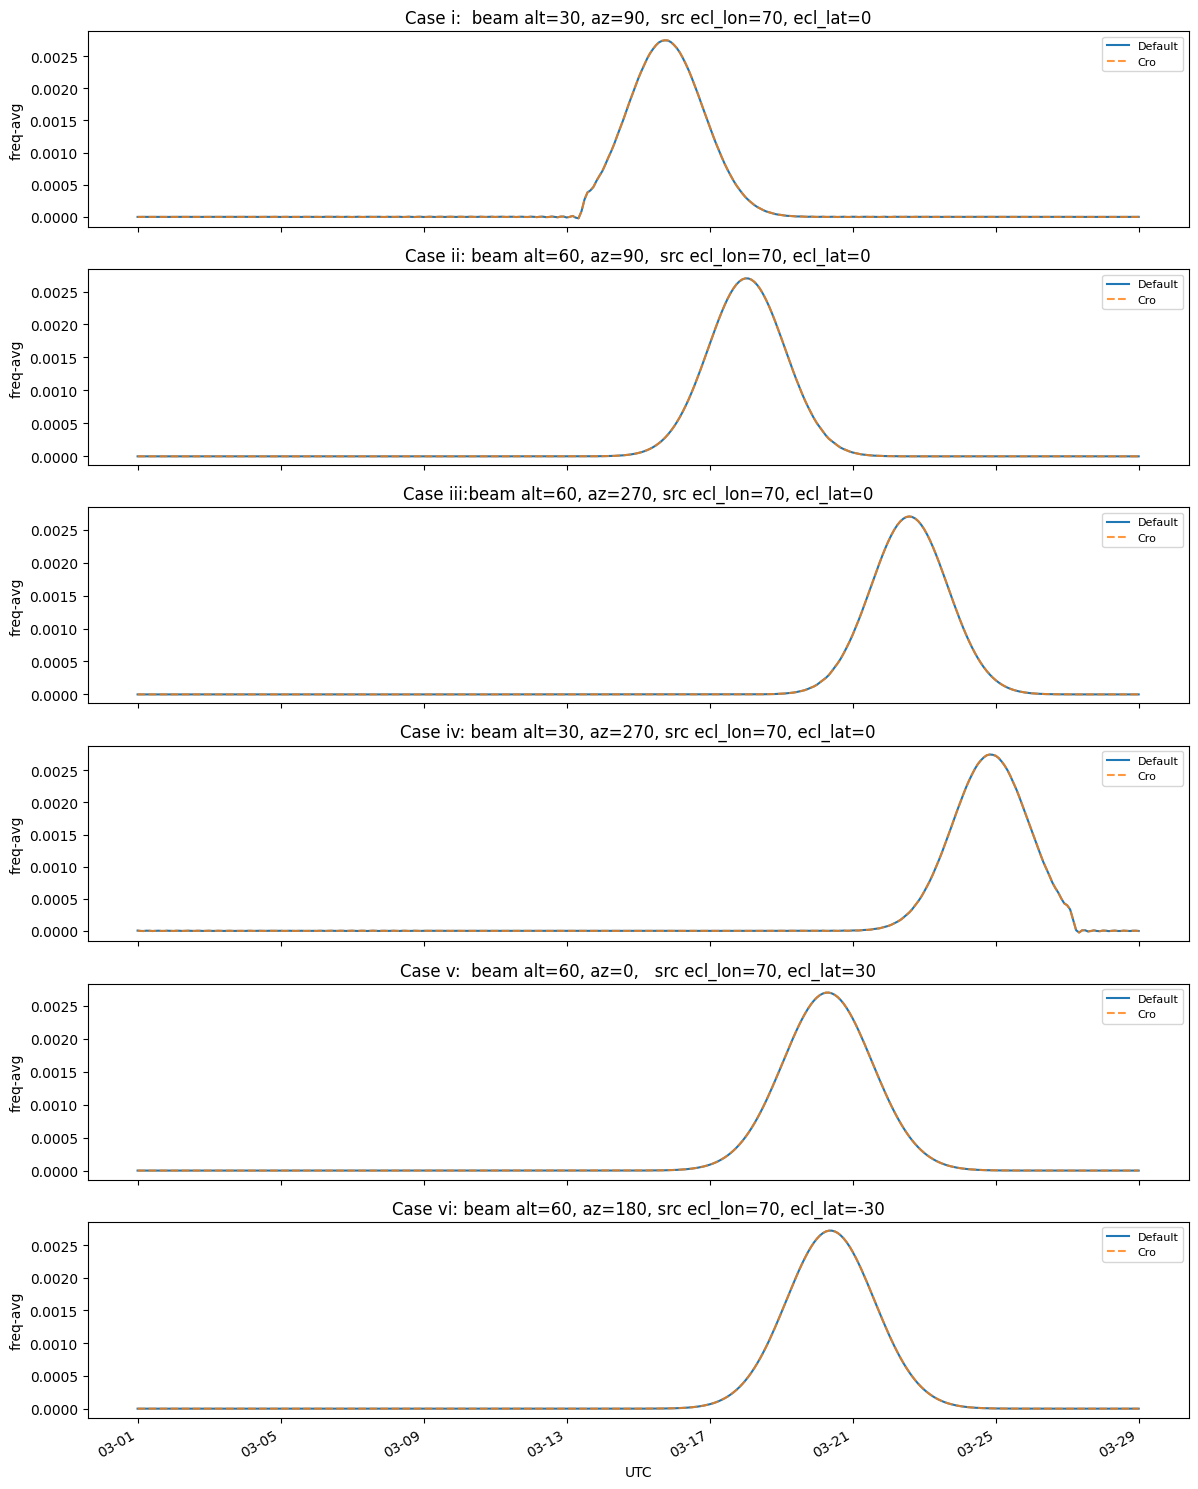

In [ ]:
fig, axes = plt.subplots(len(transit_CASES), 1, figsize=(12, 2.5 * len(transit_CASES)), sharex=True)

loaded = {}   # name -> (D_def, D_cro, sig_def, sig_cro, times_dt)

for ax, case in zip(axes, transit_CASES):
    def_path, cro_path = fits_paths(case['name'])
    D_def = lusee.Data(def_path)
    D_cro = lusee.Data(cro_path)
    sd = freq_avg(D_def)
    sc = freq_avg(D_cro)
    td = Time(D_def.times).datetime
    tc = Time(D_cro.times).datetime
    loaded[case['name']] = (D_def, D_cro, sd, sc, td)

    ax.plot(td, sd, label='Default')
    ax.plot(tc, sc, '--', label='Cro', alpha=0.8)
    ax.set_title(f"Case {case['label']}")
    ax.set_ylabel('freq-avg')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

axes[-1].set_xlabel('UTC')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

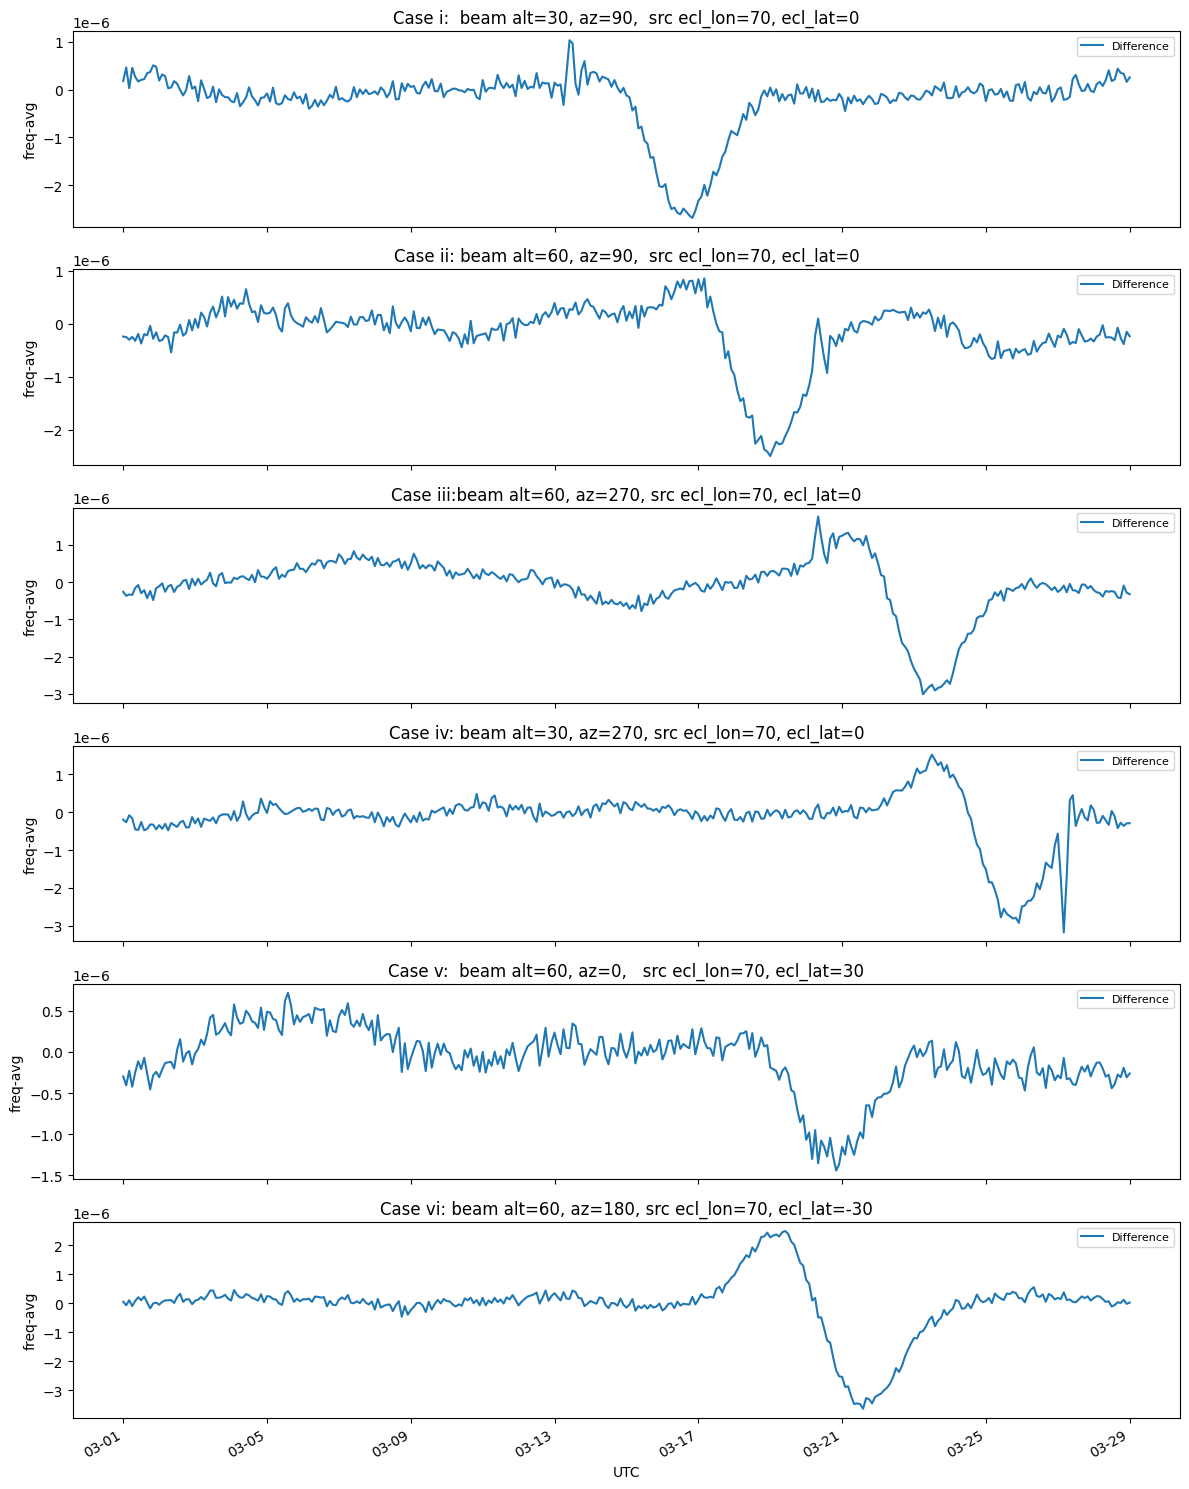

In [ ]:
fig, axes = plt.subplots(len(transit_CASES), 1, figsize=(12, 2.5 * len(transit_CASES)), sharex=True)

loaded = {}   # name -> (D_def, D_cro, sig_def, sig_cro, times_dt)

for ax, case in zip(axes, transit_CASES):
    def_path, cro_path = fits_paths(case['name'])
    D_def = lusee.Data(def_path)
    D_cro = lusee.Data(cro_path)
    sd = freq_avg(D_def)
    sc = freq_avg(D_cro)
    td = Time(D_def.times).datetime
    tc = Time(D_cro.times).datetime
    loaded[case['name']] = (D_def, D_cro, sd, sc, td)

    ax.plot(td, sd-sc, label='Difference')
    ax.set_title(f"Case {case['label']}")
    ax.set_ylabel('freq-avg')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

axes[-1].set_xlabel('UTC')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Transit table: expected vs actual

**Expected** transit = time of minimum angular separation between the source sky track and the beam pointing direction (geometric prediction, no simulation).

**Actual** transit = peak in the frequency-averaged response from each simulator.

In [ ]:

rows = []

for case in transit_CASES:
    name = case['name']
    ra_deg, dec_deg = get_source_radec(case['ecl_lon'], case['ecl_lat'])

    # Expected transits (geometric)
    exp_transits = expected_transit_times(
        obs, ra_deg, dec_deg, case['beam_alt'], case['beam_az']
    )

    # Load data
    if name == 'singlepixel':
        sig_def = freq_avg(D_sp_def)
        sig_cro = freq_avg(D_sp_cro)
        times_dt = Time(D_sp_def.times).datetime
    else:
        _, _, sig_def, sig_cro, times_dt = loaded[name]

    # Actual transits from each simulator
    act_def = actual_transit_times(times_dt, sig_def)
    act_cro = actual_transit_times(times_dt, sig_cro)

    rows.append(dict(
        case=name,
        beam=f"alt={case['beam_alt']}, az={case['beam_az']}",
        source=f"ecl({case['ecl_lon']}, {case['ecl_lat']})",
        expected=exp_transits,
        actual_default=act_def,
        actual_cro=act_cro,
    ))

print(rows[0])

{'case': 'i', 'beam': 'alt=30, az=90', 'source': 'ecl(70, 0)', 'expected': [(datetime.datetime(2025, 3, 15, 18, 0), np.float64(1.4983855699975153))], 'actual_default': [(datetime.datetime(2025, 3, 15, 18, 0), np.float64(0.0027440061142905508))], 'actual_cro': [(datetime.datetime(2025, 3, 15, 18, 0), np.float64(0.002745420904830098))]}


In [8]:
from IPython.display import HTML

def fmt_transits(transits):
    if not transits:
        return "—"
    parts = []
    for t, val in transits:
        dt_str = t.strftime('%m-%d %H:%M')
        parts.append(f"{dt_str} ({val:.3g})")
    return "<br>".join(parts)

def fmt_expected(transits):
    if not transits:
        return "—"
    parts = []
    for t, sep in transits:
        dt_str = t.strftime('%m-%d %H:%M')
        parts.append(f"{dt_str} (sep={sep:.1f}°)")
    return "<br>".join(parts)

html = """
<style>
  table { border-collapse: collapse; font-family: monospace; font-size: 12px; }
  th, td { border: 1px solid #ccc; padding: 4px 8px; vertical-align: top; }
  th { background: #eee; }
</style>
<table>
<tr>
  <th>Case</th><th>Beam (alt, az)</th><th>Source</th>
  <th>Expected transit<br>(geometric min sep)</th>
  <th>Default sim peaks<br>(freq-avg value)</th>
  <th>Cro sim peaks<br>(freq-avg value)</th>
</tr>
"""

for r in rows:
    html += (
        f"<tr>"
        f"<td>{r['case']}</td>"
        f"<td>{r['beam']}</td>"
        f"<td>{r['source']}</td>"
        f"<td>{fmt_expected(r['expected'])}</td>"
        f"<td>{fmt_transits(r['actual_default'])}</td>"
        f"<td>{fmt_transits(r['actual_cro'])}</td>"
        f"</tr>\n"
    )

html += "</table>"
HTML(html)

Case,"Beam (alt, az)",Source,Expected transit(geometric min sep),Default sim peaks(freq-avg value),Cro sim peaks(freq-avg value)
i,"alt=30, az=90","ecl(70, 0)",03-15 18:00 (sep=1.5°),03-15 18:00 (0.00274),03-15 18:00 (0.00275)
ii,"alt=60, az=90","ecl(70, 0)",03-18 00:00 (sep=1.5°),03-18 00:00 (0.0027),03-18 00:00 (0.0027)
iii,"alt=60, az=270","ecl(70, 0)",03-22 14:00 (sep=1.5°),03-22 14:00 (0.0027),03-22 14:00 (0.0027)
iv,"alt=30, az=270","ecl(70, 0)",03-24 20:00 (sep=1.5°),03-24 20:00 (0.00275),03-24 20:00 (0.00275)
v,"alt=60, az=0","ecl(70, 30)",03-20 06:00 (sep=1.5°),03-20 08:00 (0.0027),03-20 08:00 (0.0027)
vi,"alt=60, az=180","ecl(70, -30)",03-20 08:00 (sep=1.5°),03-20 10:00 (0.00272),03-20 10:00 (0.00272)


In [9]:
from datetime import timezone

def to_unix(dt):
    """Convert a naive datetime (UTC) to unix seconds."""
    return dt.replace(tzinfo=timezone.utc).timestamp()

def match_transits(expected, actual):
    """
    For each expected transit find the nearest actual transit.
    Returns list of (exp_dt, act_dt, offset_hours).
    """
    if not expected or not actual:
        return []
    matches = []
    act_unix = np.array([to_unix(t) for t, _ in actual])
    for exp_dt, sep in expected:
        exp_unix = to_unix(exp_dt)
        idx = np.argmin(np.abs(act_unix - exp_unix))
        act_dt = actual[idx][0]
        offset_h = (to_unix(act_dt) - exp_unix) / 3600.0
        matches.append((exp_dt, act_dt, offset_h))
    return matches

html2 = """
<style>
  table { border-collapse: collapse; font-family: monospace; font-size: 12px; }
  th, td { border: 1px solid #ccc; padding: 4px 8px; vertical-align: top; }
  th { background: #eee; }
</style>
<table>
<tr>
  <th>Case</th>
  <th>Expected transit</th>
  <th>Default actual</th><th>Default offset (h)</th>
  <th>Cro actual</th><th>Cro offset (h)</th>
</tr>
"""

for r in rows:
    m_def = match_transits(r['expected'], r['actual_default'])
    m_cro = match_transits(r['expected'], r['actual_cro'])
    n = max(len(m_def), len(m_cro), len(r['expected']))
    if n == 0:
        html2 += f"<tr><td>{r['case']}</td><td colspan=5>no transits detected</td></tr>\n"
        continue
    for i in range(n):
        case_cell = f"<td rowspan={n}>{r['case']}</td>" if i == 0 else ""
        exp_str = m_def[i][0].strftime('%m-%d %H:%M') if i < len(m_def) else "—"
        def_str = m_def[i][1].strftime('%m-%d %H:%M') if i < len(m_def) else "—"
        def_off = f"{m_def[i][2]:+.2f}" if i < len(m_def) else "—"
        cro_str = m_cro[i][1].strftime('%m-%d %H:%M') if i < len(m_cro) else "—"
        cro_off = f"{m_cro[i][2]:+.2f}" if i < len(m_cro) else "—"
        html2 += (
            f"<tr>{case_cell}"
            f"<td>{exp_str}</td>"
            f"<td>{def_str}</td><td>{def_off}</td>"
            f"<td>{cro_str}</td><td>{cro_off}</td>"
            f"</tr>\n"
        )

html2 += "</table>"
HTML(html2)

Case,Expected transit,Default actual,Default offset (h),Cro actual,Cro offset (h)
i,03-15 18:00,03-15 18:00,+0.00,03-15 18:00,+0.00
ii,03-18 00:00,03-18 00:00,+0.00,03-18 00:00,+0.00
iii,03-22 14:00,03-22 14:00,+0.00,03-22 14:00,+0.00
iv,03-24 20:00,03-24 20:00,+0.00,03-24 20:00,+0.00
v,03-20 06:00,03-20 08:00,+2.00,03-20 08:00,+2.00
vi,03-20 08:00,03-20 10:00,+2.00,03-20 10:00,+2.00
